# Imports

In [155]:
%pip install -q requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement requirements.txt (from versions: none)
ERROR: No matching distribution found for requirements.txt


In [156]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants

## Control

In [157]:
FETCH_DATA = False
SAVE_RESULT = True

## Routes

In [158]:
BITCOIN_DATA = 'bitcoin.csv'
RESULT_DATA = 'result.csv'

# Market

In [159]:
TRADING_DAYS_PER_YEAR = 365

## Dataset

In [160]:
TICKER = "BTC-USD"
START_DATE = "2024-10-01"
END_DATE = "2025-10-01"

### Column names

In [161]:
RETURN = 'Return'
PLUS_DM = 'PDM'
MINUS_DM = 'MDM'
TR = 'TR'
ATR = 'ATR'
SMA_PLUS_DM = 'SMA+DM'
SMA_MINUS_DM = 'SMA-DM'
PLUS_DI = 'PDI'
MINUS_DI = 'MDI'
DX = 'DX'
ADX = 'ADX'
MARKET_STATE = 'MARKET_STATE'
SMA_SHORT = 'SMA_SHORT'
SMA_LONG = 'SMA_LONG'
SMA_SIGNAL = 'SMA_SIGNAL'
SMA_CROSSOVER = 'SMA_CROSSOVER'
GAIN = 'GAIN'
LOSS = 'LOSS'
AVERAGE_GAIN = 'AVERAGE_GAIN'
AVERAGE_LOSS = 'AVERAGE_LOSS'
RS = 'RS'
RSI = 'RSI'
RSI_SIGNAL = 'RSI_SIGNAL'
RSI_CROSSOVER = 'RSI_CROSSOVER'
FINAL_STRATEGY = 'FINAL_STRATEGY'
POSITION = 'POSITION'
STRATEGY_RETURN = 'STRATEGY_RETURN'
PORTFOLIO = 'PORTFOLIO'
MARKET_RETURN = 'MARKET_RETURN'

## Indicator

In [162]:
THETA_ADX = 25
ADX_LOOKBACK = 14

## Strategy

In [163]:
SMA_SHORT = 20
SMA_LONG = 50
RSI_LOOKBACK = 14

INITIAL_ASSET = 1000

# Configuration

In [164]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Functions

## Fetching data

In [165]:
def fetch_from_yfinance(ticker: str, route: str, start_date, end_date, fetch: bool=True):
    if fetch:
        df = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date
        )
        df.to_csv(route)
        df = pd.read_csv(route, skiprows=[1, 2], header=0)
        df = df.rename(columns={'Price': 'Date'})
        df = df.set_index('Date')
        df.to_csv(route)
    else:
        df = pd.read_csv(route)
    return df

# Fetch data

In [166]:
df = fetch_from_yfinance(TICKER, BITCOIN_DATA, START_DATE, END_DATE, FETCH_DATA)
df.head()

,Date,Close,High,Low,Open,Volume,Return
0,2024-10-01,60837.01,64110.98,60189.28,63335.61,50220923500,NaN
1,2024-10-02,60632.79,62357.69,59996.95,60836.32,40762722398,-0.00
2,2024-10-03,60759.40,61469.04,59878.80,60632.48,36106447279,0.00
3,2024-10-04,62067.48,62465.99,60459.94,60754.62,29585472513,0.02
4,2024-10-05,62089.95,62371.02,61689.58,62067.61,13305410749,0.00


# Preprocessing

# Indicators

## ADX

### Directional Moving (DM)

$$ +DM_t = H_{t} - H_{t-1} $$
$$ -DM_t = L_{t-1} - L_{t} $$

In [167]:
df['DMP'] = df['High'].diff()
df['DMN'] = df['Low'].diff()

def apply_dm_logic(row):
    dmp = row['DMP']
    dmn = row['DMN']
    
    dm_plus = dmp if dmp > 0 else 0
    dm_minus = -dmn if dmn < 0 else 0 
    
    if dm_plus > 0 and dm_minus > 0:
        if dm_plus > dm_minus:
            dm_minus = 0
        else:
            dm_plus = 0
            
    return pd.Series({'DM_Plus': dm_plus, 'DM_Minus': dm_minus})

dm_results = df.apply(apply_dm_logic, axis=1)

df[PLUS_DM] = dm_results['DM_Plus']
df[MINUS_DM] = dm_results['DM_Minus']

df = df.drop(columns=['DMP', 'DMN'])
df.head()

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM
0,2024-10-01,60837.01,64110.98,60189.28,63335.61,50220923500,NaN,0.00,0.00
1,2024-10-02,60632.79,62357.69,59996.95,60836.32,40762722398,-0.00,0.00,192.33
2,2024-10-03,60759.40,61469.04,59878.80,60632.48,36106447279,0.00,0.00,118.14
3,2024-10-04,62067.48,62465.99,60459.94,60754.62,29585472513,0.02,996.95,0.00
4,2024-10-05,62089.95,62371.02,61689.58,62067.61,13305410749,0.00,0.00,0.00


### True Range (TR)

$$TR_{t} = max(H_{t}-L_{t}, |H_{t}-C_{t-1}|, |L_{t}-C_{t-1}|)$$

In [168]:
df['High_Low'] = df['High'] - df['Low']
df['High_PrevClose'] = abs(df['High'] - df['Close'].shift(1))
df['Low_PrevClose'] = abs(df['Low'] - df['Close'].shift(1))
df[TR] = df[['High_Low', 'High_PrevClose', 'Low_PrevClose']].max(axis=1)

df = df.drop(columns=['High_Low', 'High_PrevClose', 'Low_PrevClose'])
df.head()

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR
0,2024-10-01,60837.01,64110.98,60189.28,63335.61,50220923500,NaN,0.00,0.00,3921.70
1,2024-10-02,60632.79,62357.69,59996.95,60836.32,40762722398,-0.00,0.00,192.33,2360.74
2,2024-10-03,60759.40,61469.04,59878.80,60632.48,36106447279,0.00,0.00,118.14,1590.23
3,2024-10-04,62067.48,62465.99,60459.94,60754.62,29585472513,0.02,996.95,0.00,2006.05
4,2024-10-05,62089.95,62371.02,61689.58,62067.61,13305410749,0.00,0.00,0.00,681.44


### Average True Range (ATR)

$$ATR_{t} = \frac{1}{n} \sum_{i=t-n+1}^{t} TR_{i}$$

In [169]:
df[ATR] = df[TR].rolling(window=ADX_LOOKBACK).mean()

df.head(ADX_LOOKBACK*2).tail(ADX_LOOKBACK)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR
14,2024-10-15,67041.11,67881.68,64809.20,66050.37,48863870879,0.02,1399.19,0.00,3072.48,2045.19
15,2024-10-16,67612.72,68375.29,66758.73,67042.46,38195189534,0.01,493.61,0.00,1616.56,1992.03
16,2024-10-17,67399.84,67912.21,66647.39,67617.08,32790898511,-0.00,0.00,111.34,1264.82,1968.79
17,2024-10-18,68418.79,68969.75,67177.82,67419.11,36857165014,0.02,1057.54,0.00,1791.93,1953.49
18,2024-10-19,68362.73,68668.01,68024.64,68418.98,14443497908,-0.00,0.00,0.00,643.37,1950.77
19,2024-10-20,69001.70,69359.01,68105.72,68364.18,18975847518,0.01,691.00,0.00,1253.29,1959.84
20,2024-10-21,67367.85,69462.73,66829.85,69002.00,37498611780,-0.02,0.00,1275.87,2632.88,1984.25
21,2024-10-22,67361.41,67801.58,66581.37,67360.70,31808472566,-0.00,0.00,248.48,1220.21,1976.35
22,2024-10-23,66432.20,67402.74,65188.04,67362.38,32263980353,-0.01,0.00,1393.33,2214.71,1977.81
23,2024-10-24,68161.05,68798.96,66454.10,66653.70,31414428647,0.03,1396.22,0.00,2366.77,1979.62


### Simple Moving Average Directional Movement (SMA DM)

$$SMA+DM = \frac{1}{n} \sum_{i=t-n+1}^{t}+DM_{i}$$
$$SMA-DM = \frac{1}{n} \sum_{i=t-n+1}^{t}-DM_{i}$$

In [170]:
df[SMA_PLUS_DM] = df[PLUS_DM].rolling(window=ADX_LOOKBACK).mean()
df[SMA_MINUS_DM] = df[MINUS_DM].rolling(window=ADX_LOOKBACK).mean()

df.head(ADX_LOOKBACK*2).tail(ADX_LOOKBACK)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM
14,2024-10-15,67041.11,67881.68,64809.20,66050.37,48863870879,0.02,1399.19,0.00,3072.48,2045.19,706.48,283.96
15,2024-10-16,67612.72,68375.29,66758.73,67042.46,38195189534,0.01,493.61,0.00,1616.56,1992.03,741.74,270.22
16,2024-10-17,67399.84,67912.21,66647.39,67617.08,32790898511,-0.00,0.00,111.34,1264.82,1968.79,741.74,269.74
17,2024-10-18,68418.79,68969.75,67177.82,67419.11,36857165014,0.02,1057.54,0.00,1791.93,1953.49,746.07,269.74
18,2024-10-19,68362.73,68668.01,68024.64,68418.98,14443497908,-0.00,0.00,0.00,643.37,1950.77,746.07,269.74
19,2024-10-20,69001.70,69359.01,68105.72,68364.18,18975847518,0.01,691.00,0.00,1253.29,1959.84,753.38,269.74
20,2024-10-21,67367.85,69462.73,66829.85,69002.00,37498611780,-0.02,0.00,1275.87,2632.88,1984.25,647.37,360.87
21,2024-10-22,67361.41,67801.58,66581.37,67360.70,31808472566,-0.00,0.00,248.48,1220.21,1976.35,647.37,356.55
22,2024-10-23,66432.20,67402.74,65188.04,67362.38,32263980353,-0.01,0.00,1393.33,2214.71,1977.81,647.37,346.86
23,2024-10-24,68161.05,68798.96,66454.10,66653.70,31414428647,0.03,1396.22,0.00,2366.77,1979.62,747.10,245.48


### Directional Indicator (DI)

$$+DI_{t} = (\frac{SMA+DM_{t}}{ATR_{t}}) \times 100$$
$$-DI_{t} = (\frac{SMA-DM_{t}}{ATR_{t}}) \times 100$$

In [171]:
df[PLUS_DI] = df[SMA_PLUS_DM] / df[ATR] * 100
df[MINUS_DI] = df[SMA_MINUS_DM] / df[ATR] * 100

df.head(ADX_LOOKBACK*2).tail(ADX_LOOKBACK)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM,PDI,MDI
14,2024-10-15,67041.11,67881.68,64809.20,66050.37,48863870879,0.02,1399.19,0.00,3072.48,2045.19,706.48,283.96,34.54,13.88
15,2024-10-16,67612.72,68375.29,66758.73,67042.46,38195189534,0.01,493.61,0.00,1616.56,1992.03,741.74,270.22,37.24,13.57
16,2024-10-17,67399.84,67912.21,66647.39,67617.08,32790898511,-0.00,0.00,111.34,1264.82,1968.79,741.74,269.74,37.67,13.70
17,2024-10-18,68418.79,68969.75,67177.82,67419.11,36857165014,0.02,1057.54,0.00,1791.93,1953.49,746.07,269.74,38.19,13.81
18,2024-10-19,68362.73,68668.01,68024.64,68418.98,14443497908,-0.00,0.00,0.00,643.37,1950.77,746.07,269.74,38.24,13.83
19,2024-10-20,69001.70,69359.01,68105.72,68364.18,18975847518,0.01,691.00,0.00,1253.29,1959.84,753.38,269.74,38.44,13.76
20,2024-10-21,67367.85,69462.73,66829.85,69002.00,37498611780,-0.02,0.00,1275.87,2632.88,1984.25,647.37,360.87,32.63,18.19
21,2024-10-22,67361.41,67801.58,66581.37,67360.70,31808472566,-0.00,0.00,248.48,1220.21,1976.35,647.37,356.55,32.76,18.04
22,2024-10-23,66432.20,67402.74,65188.04,67362.38,32263980353,-0.01,0.00,1393.33,2214.71,1977.81,647.37,346.86,32.73,17.54
23,2024-10-24,68161.05,68798.96,66454.10,66653.70,31414428647,0.03,1396.22,0.00,2366.77,1979.62,747.10,245.48,37.74,12.40


### Directional Index (DX)

$$DX_{t} = \frac{|(+DI_{t})-(-DI_{t})|}{|(+DI_{t})+(-DI_{t})|} \times 100$$

In [172]:
df[DX] = abs(df[PLUS_DI] - df[MINUS_DI])/abs(df[PLUS_DI] + df[MINUS_DI]) * 100

df.head(ADX_LOOKBACK*2).tail(ADX_LOOKBACK)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM,PDI,MDI,DX
14,2024-10-15,67041.11,67881.68,64809.20,66050.37,48863870879,0.02,1399.19,0.00,3072.48,2045.19,706.48,283.96,34.54,13.88,42.66
15,2024-10-16,67612.72,68375.29,66758.73,67042.46,38195189534,0.01,493.61,0.00,1616.56,1992.03,741.74,270.22,37.24,13.57,46.59
16,2024-10-17,67399.84,67912.21,66647.39,67617.08,32790898511,-0.00,0.00,111.34,1264.82,1968.79,741.74,269.74,37.67,13.70,46.66
17,2024-10-18,68418.79,68969.75,67177.82,67419.11,36857165014,0.02,1057.54,0.00,1791.93,1953.49,746.07,269.74,38.19,13.81,46.89
18,2024-10-19,68362.73,68668.01,68024.64,68418.98,14443497908,-0.00,0.00,0.00,643.37,1950.77,746.07,269.74,38.24,13.83,46.89
19,2024-10-20,69001.70,69359.01,68105.72,68364.18,18975847518,0.01,691.00,0.00,1253.29,1959.84,753.38,269.74,38.44,13.76,47.27
20,2024-10-21,67367.85,69462.73,66829.85,69002.00,37498611780,-0.02,0.00,1275.87,2632.88,1984.25,647.37,360.87,32.63,18.19,28.42
21,2024-10-22,67361.41,67801.58,66581.37,67360.70,31808472566,-0.00,0.00,248.48,1220.21,1976.35,647.37,356.55,32.76,18.04,28.97
22,2024-10-23,66432.20,67402.74,65188.04,67362.38,32263980353,-0.01,0.00,1393.33,2214.71,1977.81,647.37,346.86,32.73,17.54,30.23
23,2024-10-24,68161.05,68798.96,66454.10,66653.70,31414428647,0.03,1396.22,0.00,2366.77,1979.62,747.10,245.48,37.74,12.40,50.54


### Average Directional Index (ADX)

$$ADX_{t} = \frac{1}{n} \sum_{i=t-n+1}^{t} DX_{i}$$

In [173]:
df[ADX] = df[DX].rolling(window=ADX_LOOKBACK).mean()

df.head(ADX_LOOKBACK*3).tail(ADX_LOOKBACK)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM,PDI,MDI,DX,ADX
28,2024-10-29,72720.49,73577.21,69729.91,69910.05,58541874402,0.04,3364.95,0.00,3847.30,1932.91,706.98,282.95,36.58,14.64,42.83,39.29
29,2024-10-30,72339.54,72905.30,71411.73,72715.37,40646637831,-0.01,0.00,0.00,1493.56,1924.12,671.72,282.95,34.91,14.71,40.72,38.87
30,2024-10-31,70215.19,72662.31,69590.50,72335.05,40627912076,-0.03,0.00,1821.23,3071.81,2053.20,671.72,405.09,32.72,19.73,24.76,37.30
31,2024-11-01,69482.47,71559.02,68779.70,70216.90,49989795365,-0.01,0.00,810.80,2779.31,2123.72,596.18,463.00,28.07,21.80,12.57,34.85
32,2024-11-02,69289.27,69867.35,69033.72,69486.02,18184612091,-0.00,0.00,0.00,833.63,2137.31,596.18,463.00,27.89,21.66,12.57,32.40
33,2024-11-03,68741.12,69361.66,67482.52,69296.38,34868307655,-0.01,0.00,1551.20,1879.13,2182.02,546.82,573.80,25.06,26.30,2.41,29.19
34,2024-11-04,67811.51,69433.18,66803.65,68742.13,41184819348,-0.01,0.00,678.88,2629.53,2181.78,546.82,531.16,25.06,24.35,1.45,27.27
35,2024-11-05,69359.56,70522.79,67458.87,67811.17,46046889204,0.02,1089.61,0.00,3063.92,2313.47,624.65,513.41,27.00,22.19,9.77,25.90
36,2024-11-06,75639.08,76460.16,69322.03,69358.50,118592653963,0.09,5937.37,0.00,7138.12,2665.14,1048.75,413.89,39.35,15.53,43.41,26.84
37,2024-11-07,75904.86,76943.12,74480.42,75637.09,63467654989,0.00,482.96,0.00,2462.70,2672.00,983.52,413.89,36.81,15.49,40.76,26.14


### Market Status

In [174]:
df[MARKET_STATE] = np.where(df[ADX] > THETA_ADX, 'trending', 'sideways')

df.head(100).tail(30)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM,PDI,MDI,DX,ADX,MARKET_STATE
70,2024-12-10,96675.43,98270.16,94321.26,97441.23,104823780634,-0.01,0.00,34.66,3948.90,4117.93,945.79,470.78,22.97,11.43,33.53,21.66,sideways
71,2024-12-11,101173.03,101913.36,95747.23,96656.06,85391409936,0.05,3643.20,0.00,6166.13,4159.62,1036.77,470.78,24.92,11.32,37.54,23.23,sideways
72,2024-12-12,100043.00,102524.91,99339.95,101167.80,72073983533,-0.01,611.55,0.00,3184.96,4246.20,1080.46,470.78,25.45,11.09,39.30,24.93,sideways
73,2024-12-13,101459.26,101888.80,99233.28,100046.65,56894751583,0.01,0.00,106.67,2655.52,4201.22,934.53,478.40,22.24,11.39,32.28,25.55,trending
74,2024-12-14,101372.97,102618.88,100634.05,101451.44,40422968793,-0.00,730.08,0.00,1984.83,4246.19,986.68,478.40,23.24,11.27,34.69,26.34,trending
75,2024-12-15,104298.70,105047.54,101227.03,101373.53,51145914137,0.03,2428.66,0.00,3820.51,4367.81,1132.38,478.40,25.93,10.95,40.60,26.84,trending
76,2024-12-16,106029.72,107780.58,103322.98,104293.58,91020417816,0.02,2733.04,0.00,4457.59,4424.08,1327.60,386.45,30.01,8.74,54.91,29.26,trending
77,2024-12-17,106140.60,108268.45,105291.73,106030.69,68589364868,0.00,487.87,0.00,2976.71,4446.16,1362.45,325.49,30.64,7.32,61.43,32.96,trending
78,2024-12-18,100041.54,106470.61,100041.54,106147.30,93865656139,-0.06,0.00,5250.20,6429.07,4580.61,1154.58,700.51,25.21,15.29,24.48,33.39,trending
79,2024-12-19,97490.95,102748.15,95587.68,100070.69,97221662392,-0.03,0.00,4453.86,7160.47,4241.95,819.36,1018.64,19.32,24.01,10.84,32.70,trending


# Strategies

## SMA Crossover

### SMA Short and Long

In [175]:
df[SMA_SHORT] = df['Close'].rolling(window=SMA_SHORT).mean()
df[SMA_LONG] = df['Close'].rolling(window=SMA_LONG).mean()

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,ATR,SMA+DM,SMA-DM,PDI,MDI,DX,ADX,MARKET_STATE,20,50
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.00,0.00,0.00,1171.45,3220.32,591.20,785.95,18.36,24.41,14.14,31.75,trending,97241.36,97088.17
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.00,0.00,271.21,1521.54,3103.42,591.20,646.44,19.05,20.83,4.46,30.31,trending,96855.62,97243.30
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,0.04,3669.57,0.00,4556.73,3142.26,853.32,517.94,27.16,16.48,24.46,30.78,trending,96652.49,97487.95
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-0.05,0.00,1793.27,6579.61,3186.80,639.90,646.03,20.08,20.27,0.48,30.32,trending,96496.55,97615.55
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-0.02,0.00,3607.03,4732.48,3390.17,634.56,903.67,18.72,26.66,17.49,30.13,trending,96374.18,97669.54


### SMA Signal

In [176]:
df[SMA_SIGNAL] = np.where(df[SMA_SHORT] > df[SMA_LONG], 1, 0)
df[SMA_CROSSOVER] = df[SMA_SIGNAL].diff()
# Crossover = +1 -> Long signal
# Crossover = -1 -> Short signal

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,SMA-DM,PDI,MDI,DX,ADX,MARKET_STATE,20,50,SMA_SIGNAL,SMA_CROSSOVER
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.00,0.00,0.00,1171.45,...,785.95,18.36,24.41,14.14,31.75,trending,97241.36,97088.17,1,0.00
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.00,0.00,271.21,1521.54,...,646.44,19.05,20.83,4.46,30.31,trending,96855.62,97243.30,0,-1.00
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,0.04,3669.57,0.00,4556.73,...,517.94,27.16,16.48,24.46,30.78,trending,96652.49,97487.95,0,0.00
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-0.05,0.00,1793.27,6579.61,...,646.03,20.08,20.27,0.48,30.32,trending,96496.55,97615.55,0,0.00
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-0.02,0.00,3607.03,4732.48,...,903.67,18.72,26.66,17.49,30.13,trending,96374.18,97669.54,0,0.00


## RSI Mean Reversion

### Return
$$\Delta_t = C_{t} - C_{t-1}$$

In [177]:
df[RETURN] = df['Close'].pct_change() * 100

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,SMA-DM,PDI,MDI,DX,ADX,MARKET_STATE,20,50,SMA_SIGNAL,SMA_CROSSOVER
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,785.95,18.36,24.41,14.14,31.75,trending,97241.36,97088.17,1,0.00
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,646.44,19.05,20.83,4.46,30.31,trending,96855.62,97243.30,0,-1.00
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,517.94,27.16,16.48,24.46,30.78,trending,96652.49,97487.95,0,0.00
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,646.03,20.08,20.27,0.48,30.32,trending,96496.55,97615.55,0,0.00
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,903.67,18.72,26.66,17.49,30.13,trending,96374.18,97669.54,0,0.00


### Gain and Loss
$$G_{t} = max(\Delta_t,0)$$
$$L_{t} = max(-\Delta_t,0)$$

In [178]:
df[GAIN] = np.maximum(df[RETURN], 0) * 100
df[LOSS] = np.maximum(-df[RETURN], 0) * 100

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,MDI,DX,ADX,MARKET_STATE,20,50,SMA_SIGNAL,SMA_CROSSOVER,GAIN,LOSS
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,24.41,14.14,31.75,trending,97241.36,97088.17,1,0.00,13.13,0.00
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,20.83,4.46,30.31,trending,96855.62,97243.30,0,-1.00,8.01,0.00
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,16.48,24.46,30.78,trending,96652.49,97487.95,0,0.00,382.76,0.00
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,20.27,0.48,30.32,trending,96496.55,97615.55,0,0.00,0.00,505.04
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,26.66,17.49,30.13,trending,96374.18,97669.54,0,0.00,0.00,193.88


### Average Gain and Loss
$$\bar{G}_{t} = \frac{1}{n} \sum_{i=t-n+1}^{t} G_i$$
$$\bar{L}_{t} = \frac{1}{n} \sum_{i=t-n+1}^{t} L_i$$

In [179]:
df[AVERAGE_GAIN] = df[GAIN].rolling(window=RSI_LOOKBACK).mean()
df[AVERAGE_LOSS] = df[LOSS].rolling(window=RSI_LOOKBACK).mean()

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,ADX,MARKET_STATE,20,50,SMA_SIGNAL,SMA_CROSSOVER,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,31.75,trending,97241.36,97088.17,1,0.00,13.13,0.00,84.42,75.12
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,30.31,trending,96855.62,97243.30,0,-1.00,8.01,0.00,84.99,59.54
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,30.78,trending,96652.49,97487.95,0,0.00,382.76,0.00,112.33,56.40
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,30.32,trending,96496.55,97615.55,0,0.00,0.00,505.04,82.23,92.47
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,30.13,trending,96374.18,97669.54,0,0.00,0.00,193.88,77.72,106.32


### Relative Strength (RS)

$$RS_{t} = \frac{\bar{G}_{t}}{\bar{L}_{t}}$$

In [180]:
df[RS] = df[AVERAGE_GAIN] / df[AVERAGE_LOSS]

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,MARKET_STATE,20,50,SMA_SIGNAL,SMA_CROSSOVER,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,trending,97241.36,97088.17,1,0.00,13.13,0.00,84.42,75.12,1.12
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,trending,96855.62,97243.30,0,-1.00,8.01,0.00,84.99,59.54,1.43
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,trending,96652.49,97487.95,0,0.00,382.76,0.00,112.33,56.40,1.99
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,trending,96496.55,97615.55,0,0.00,0.00,505.04,82.23,92.47,0.89
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,trending,96374.18,97669.54,0,0.00,0.00,193.88,77.72,106.32,0.73


### Relative Strength Index (RSI)
$$RSI_{t} = 100 - \frac{100}{1+RS_{t}}$$

In [181]:
df[RSI] = 100 - 100 / (1 + df[RS])

df.head(100).tail(5)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,20,50,SMA_SIGNAL,SMA_CROSSOVER,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,97241.36,97088.17,1,0.00,13.13,0.00,84.42,75.12,1.12,52.92
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,96855.62,97243.30,0,-1.00,8.01,0.00,84.99,59.54,1.43,58.80
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,96652.49,97487.95,0,0.00,382.76,0.00,112.33,56.40,1.99,66.58
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,96496.55,97615.55,0,0.00,0.00,505.04,82.23,92.47,0.89,47.07
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,96374.18,97669.54,0,0.00,0.00,193.88,77.72,106.32,0.73,42.23


### RSI Signal

In [182]:
conditions = [df[RSI] > 70, df[RSI] < 30]
choices =    [      -1      ,       +1      ]
df[RSI_SIGNAL] = np.select(conditions, choices, default=0)
df['RSI-Crossover-temp'] = df[RSI_SIGNAL].diff()
df[RSI_CROSSOVER] = np.where(df[RSI_SIGNAL] != 0, df['RSI-Crossover-temp'], 0)
df = df.drop(columns=['RSI-Crossover-temp'])

df.head(100).tail(20)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,SMA_SIGNAL,SMA_CROSSOVER,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER
80,2024-12-20,97755.93,98098.91,92175.18,97484.70,105634083408,0.27,0.00,3412.50,5923.73,...,1,0.00,27.18,0.00,87.90,100.23,0.88,46.72,0,0.00
81,2024-12-21,97224.73,99507.10,96426.52,97756.20,51765334294,-0.54,1408.19,0.00,3080.58,...,1,0.00,0.00,54.34,87.88,104.11,0.84,45.77,0,0.00
82,2024-12-22,95104.94,97360.27,94202.19,97218.32,43147981314,-2.18,0.00,2224.34,3158.08,...,1,0.00,0.00,218.03,78.50,119.68,0.66,39.61,0,0.00
83,2024-12-23,94686.24,96416.21,92403.13,95099.39,65239002919,-0.44,0.00,1799.05,4013.08,...,1,0.00,0.00,44.02,78.50,95.99,0.82,44.99,0,0.00
84,2024-12-24,98676.09,99404.06,93448.02,94684.34,47114953674,4.21,2987.85,0.00,5956.05,...,1,0.00,421.38,0.00,108.60,90.44,1.20,54.56,0,0.00
85,2024-12-25,99299.20,99478.75,97593.47,98675.91,33700394629,0.63,74.69,0.00,1885.28,...,1,0.00,63.15,0.00,79.88,90.44,0.88,46.90,0,0.00
86,2024-12-26,95795.52,99884.57,95137.88,99297.70,47054980873,-3.53,0.00,2455.59,4746.69,...,1,0.00,0.00,352.84,79.88,107.67,0.74,42.59,0,0.00
87,2024-12-27,94164.86,97294.84,93310.74,95704.98,52419934565,-1.70,0.00,1827.14,3984.10,...,1,0.00,0.00,170.22,69.77,119.82,0.58,36.80,0,0.00
88,2024-12-28,95163.93,95525.90,94014.29,94160.19,24107436185,1.06,0.00,0.00,1511.61,...,1,0.00,106.10,0.00,77.35,119.22,0.65,39.35,0,0.00
89,2024-12-29,93530.23,95174.88,92881.79,95174.05,29635885267,-1.72,0.00,1132.50,2293.09,...,1,0.00,0.00,171.67,56.73,131.48,0.43,30.14,0,0.00


## Final strategy

In [183]:
df[FINAL_STRATEGY] = np.where(df[MARKET_STATE] == 'trending', df[SMA_CROSSOVER], df[RSI_CROSSOVER])

df.head(100).tail(20)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,SMA_CROSSOVER,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER,FINAL_STRATEGY
80,2024-12-20,97755.93,98098.91,92175.18,97484.70,105634083408,0.27,0.00,3412.50,5923.73,...,0.00,27.18,0.00,87.90,100.23,0.88,46.72,0,0.00,0.00
81,2024-12-21,97224.73,99507.10,96426.52,97756.20,51765334294,-0.54,1408.19,0.00,3080.58,...,0.00,0.00,54.34,87.88,104.11,0.84,45.77,0,0.00,0.00
82,2024-12-22,95104.94,97360.27,94202.19,97218.32,43147981314,-2.18,0.00,2224.34,3158.08,...,0.00,0.00,218.03,78.50,119.68,0.66,39.61,0,0.00,0.00
83,2024-12-23,94686.24,96416.21,92403.13,95099.39,65239002919,-0.44,0.00,1799.05,4013.08,...,0.00,0.00,44.02,78.50,95.99,0.82,44.99,0,0.00,0.00
84,2024-12-24,98676.09,99404.06,93448.02,94684.34,47114953674,4.21,2987.85,0.00,5956.05,...,0.00,421.38,0.00,108.60,90.44,1.20,54.56,0,0.00,0.00
85,2024-12-25,99299.20,99478.75,97593.47,98675.91,33700394629,0.63,74.69,0.00,1885.28,...,0.00,63.15,0.00,79.88,90.44,0.88,46.90,0,0.00,0.00
86,2024-12-26,95795.52,99884.57,95137.88,99297.70,47054980873,-3.53,0.00,2455.59,4746.69,...,0.00,0.00,352.84,79.88,107.67,0.74,42.59,0,0.00,0.00
87,2024-12-27,94164.86,97294.84,93310.74,95704.98,52419934565,-1.70,0.00,1827.14,3984.10,...,0.00,0.00,170.22,69.77,119.82,0.58,36.80,0,0.00,0.00
88,2024-12-28,95163.93,95525.90,94014.29,94160.19,24107436185,1.06,0.00,0.00,1511.61,...,0.00,106.10,0.00,77.35,119.22,0.65,39.35,0,0.00,0.00
89,2024-12-29,93530.23,95174.88,92881.79,95174.05,29635885267,-1.72,0.00,1132.50,2293.09,...,0.00,0.00,171.67,56.73,131.48,0.43,30.14,0,0.00,0.00


In [184]:
if SAVE_RESULT:
    df.to_csv(RESULT_DATA)

# Backtesting

## Positions

In [185]:
signals = df[FINAL_STRATEGY].values
returns = df[RETURN].values

current_position = 0
positions = np.zeros(len(signals))

# Determine positions based on signals
for i in range(len(signals)):
    if signals[i] == 1:  # Signal to go long
        current_position = 1
    elif signals[i] == -1:  # Signal to go short
        current_position = -1
    # If signal is 0, maintain current position
    positions[i] = current_position

df[POSITION] = positions
df.head(100).tail(10)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,GAIN,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER,FINAL_STRATEGY,POSITION
90,2024-12-30,92643.21,94903.32,91317.13,93527.20,56188003691,-0.95,0.00,1564.66,3586.19,...,0.00,94.84,44.88,138.25,0.32,24.50,1,1.00,0.00,1.00
91,2024-12-31,93429.20,96090.60,91914.03,92643.25,43625106843,0.85,1187.28,0.00,4176.57,...,84.84,0.00,50.19,138.25,0.36,26.63,1,0.00,0.00,1.00
92,2025-01-01,94419.76,94929.87,92788.12,93425.10,24519888919,1.06,0.00,0.00,2141.74,...,106.02,0.00,57.76,97.21,0.59,37.27,0,0.00,0.00,1.00
93,2025-01-02,96886.88,97739.82,94201.57,94416.29,46009564411,2.61,2809.95,0.00,3538.25,...,261.29,0.00,76.43,79.00,0.97,49.17,0,0.00,0.00,1.00
94,2025-01-03,98107.43,98956.91,96034.62,96881.73,35611391163,1.26,1217.09,0.00,2922.30,...,125.98,0.00,83.48,79.00,1.06,51.38,0,0.00,0.00,1.00
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,13.13,0.00,84.42,75.12,1.12,52.92,0,0.00,0.00,1.00
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,8.01,0.00,84.99,59.54,1.43,58.80,0,0.00,-1.00,-1.00
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,382.76,0.00,112.33,56.40,1.99,66.58,0,0.00,0.00,-1.00
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,0.00,505.04,82.23,92.47,0.89,47.07,0,0.00,0.00,-1.00
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,0.00,193.88,77.72,106.32,0.73,42.23,0,0.00,0.00,-1.00


## Strategy Return

In [186]:
df[STRATEGY_RETURN] = df[POSITION] * df[RETURN]
df[STRATEGY_RETURN] = df[STRATEGY_RETURN].fillna(0)
df.head(100).tail(10)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,LOSS,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER,FINAL_STRATEGY,POSITION,STRATEGY_RETURN
90,2024-12-30,92643.21,94903.32,91317.13,93527.20,56188003691,-0.95,0.00,1564.66,3586.19,...,94.84,44.88,138.25,0.32,24.50,1,1.00,0.00,1.00,-0.95
91,2024-12-31,93429.20,96090.60,91914.03,92643.25,43625106843,0.85,1187.28,0.00,4176.57,...,0.00,50.19,138.25,0.36,26.63,1,0.00,0.00,1.00,0.85
92,2025-01-01,94419.76,94929.87,92788.12,93425.10,24519888919,1.06,0.00,0.00,2141.74,...,0.00,57.76,97.21,0.59,37.27,0,0.00,0.00,1.00,1.06
93,2025-01-02,96886.88,97739.82,94201.57,94416.29,46009564411,2.61,2809.95,0.00,3538.25,...,0.00,76.43,79.00,0.97,49.17,0,0.00,0.00,1.00,2.61
94,2025-01-03,98107.43,98956.91,96034.62,96881.73,35611391163,1.26,1217.09,0.00,2922.30,...,0.00,83.48,79.00,1.06,51.38,0,0.00,0.00,1.00,1.26
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,0.00,84.42,75.12,1.12,52.92,0,0.00,0.00,1.00,0.13
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,0.00,84.99,59.54,1.43,58.80,0,0.00,-1.00,-1.00,-0.08
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,0.00,112.33,56.40,1.99,66.58,0,0.00,0.00,-1.00,-3.83
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,505.04,82.23,92.47,0.89,47.07,0,0.00,0.00,-1.00,5.05
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,193.88,77.72,106.32,0.73,42.23,0,0.00,0.00,-1.00,1.94


## Portfolio

In [187]:
portfolio_values = np.zeros(len(df) + 1)
portfolio_values[0] = INITIAL_ASSET

for i in range(len(df)):
    portfolio_values[i + 1] = portfolio_values[i] * (1 + df[STRATEGY_RETURN].iloc[i] / 100)

df[PORTFOLIO] = portfolio_values[1:]
df.head(100).tail(10)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,AVERAGE_GAIN,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER,FINAL_STRATEGY,POSITION,STRATEGY_RETURN,PORTFOLIO
90,2024-12-30,92643.21,94903.32,91317.13,93527.20,56188003691,-0.95,0.00,1564.66,3586.19,...,44.88,138.25,0.32,24.50,1,1.00,0.00,1.00,-0.95,722.47
91,2024-12-31,93429.20,96090.60,91914.03,92643.25,43625106843,0.85,1187.28,0.00,4176.57,...,50.19,138.25,0.36,26.63,1,0.00,0.00,1.00,0.85,728.60
92,2025-01-01,94419.76,94929.87,92788.12,93425.10,24519888919,1.06,0.00,0.00,2141.74,...,57.76,97.21,0.59,37.27,0,0.00,0.00,1.00,1.06,736.32
93,2025-01-02,96886.88,97739.82,94201.57,94416.29,46009564411,2.61,2809.95,0.00,3538.25,...,76.43,79.00,0.97,49.17,0,0.00,0.00,1.00,2.61,755.56
94,2025-01-03,98107.43,98956.91,96034.62,96881.73,35611391163,1.26,1217.09,0.00,2922.30,...,83.48,79.00,1.06,51.38,0,0.00,0.00,1.00,1.26,765.08
95,2025-01-04,98236.23,98734.43,97562.98,98106.99,22342608078,0.13,0.00,0.00,1171.45,...,84.42,75.12,1.12,52.92,0,0.00,0.00,1.00,0.13,766.09
96,2025-01-05,98314.96,98813.30,97291.77,98233.91,20525254825,0.08,0.00,271.21,1521.54,...,84.99,59.54,1.43,58.80,0,0.00,-1.00,-1.00,-0.08,765.47
97,2025-01-06,102078.09,102482.88,97926.15,98314.95,51823432705,3.83,3669.57,0.00,4556.73,...,112.33,56.40,1.99,66.58,0,0.00,0.00,-1.00,-3.83,736.17
98,2025-01-07,96922.70,102712.48,96132.88,102248.85,58685738547,-5.05,0.00,1793.27,6579.61,...,82.23,92.47,0.89,47.07,0,0.00,0.00,-1.00,5.05,773.35
99,2025-01-08,95043.52,97258.32,92525.84,96924.16,63875859171,-1.94,0.00,3607.03,4732.48,...,77.72,106.32,0.73,42.23,0,0.00,0.00,-1.00,1.94,788.35


## Market Return

In [188]:
df[MARKET_RETURN] = INITIAL_ASSET * (1 + df[RETURN] / 100).cumprod()
df.loc[0, MARKET_RETURN] = INITIAL_ASSET
df.head(10)

,Date,Close,High,Low,Open,Volume,Return,PDM,MDM,TR,...,AVERAGE_LOSS,RS,RSI,RSI_SIGNAL,RSI_CROSSOVER,FINAL_STRATEGY,POSITION,STRATEGY_RETURN,PORTFOLIO,MARKET_RETURN
0,2024-10-01,60837.01,64110.98,60189.28,63335.61,50220923500,NaN,0.00,0.00,3921.70,...,NaN,NaN,NaN,0,0.00,0.00,0.00,0.00,1000.00,1000.00
1,2024-10-02,60632.79,62357.69,59996.95,60836.32,40762722398,-0.34,0.00,192.33,2360.74,...,NaN,NaN,NaN,0,0.00,0.00,0.00,-0.00,1000.00,996.64
2,2024-10-03,60759.40,61469.04,59878.80,60632.48,36106447279,0.21,0.00,118.14,1590.23,...,NaN,NaN,NaN,0,0.00,0.00,0.00,0.00,1000.00,998.72
3,2024-10-04,62067.48,62465.99,60459.94,60754.62,29585472513,2.15,996.95,0.00,2006.05,...,NaN,NaN,NaN,0,0.00,0.00,0.00,0.00,1000.00,1020.23
4,2024-10-05,62089.95,62371.02,61689.58,62067.61,13305410749,0.04,0.00,0.00,681.44,...,NaN,NaN,NaN,0,0.00,0.00,0.00,0.00,1000.00,1020.60
5,2024-10-06,62818.95,62959.57,61833.15,62084.99,14776233667,1.17,588.55,0.00,1126.42,...,NaN,NaN,NaN,0,0.00,0.00,0.00,0.00,1000.00,1032.58
6,2024-10-07,62236.66,64443.71,62152.55,62819.11,34253562610,-0.93,1484.14,0.00,2291.16,...,NaN,NaN,NaN,0,0.00,0.00,0.00,-0.00,1000.00,1023.01
7,2024-10-08,62131.97,63174.30,61843.56,62221.64,28134475157,-0.17,0.00,308.99,1330.74,...,NaN,NaN,NaN,0,0.00,0.00,0.00,-0.00,1000.00,1021.29
8,2024-10-09,60582.10,62508.84,60314.61,62131.73,27670982363,-2.49,0.00,1528.95,2194.22,...,NaN,NaN,NaN,0,0.00,0.00,0.00,-0.00,1000.00,995.81
9,2024-10-10,60274.50,61236.72,58895.21,60581.93,30452813570,-0.51,0.00,1419.41,2341.52,...,NaN,NaN,NaN,0,0.00,0.00,0.00,-0.00,1000.00,990.75


# Evaluation

## Plots

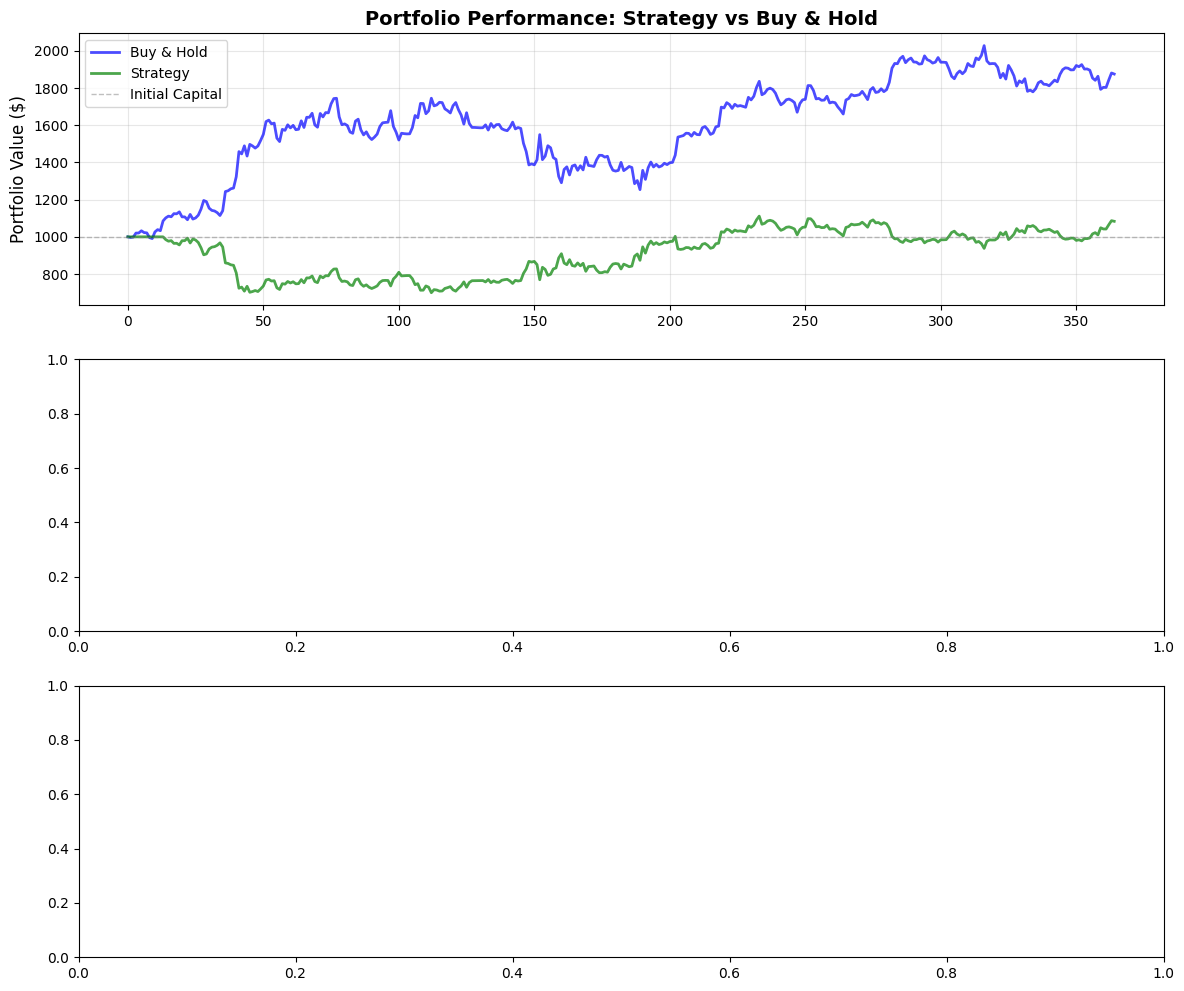

In [189]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Portfolio Value Over Time
ax1 = axes[0]
ax1.plot(df.index, df[MARKET_RETURN], 
        label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
ax1.plot(df.index, df[PORTFOLIO], 
        label='Strategy', linewidth=2, alpha=0.7, color='green')
ax1.axhline(y=INITIAL_ASSET, color='gray', linestyle='--', 
            linewidth=1, alpha=0.5, label='Initial Capital')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.set_title('Portfolio Performance: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

In [190]:

# # Plot 2: Drawdown
# ax2 = axes[1]
# _, drawdown = self.calculate_maximum_drawdown()
# ax2.fill_between(df.index, drawdown * 100, 0, alpha=0.3, color='red')
# ax2.plot(df.index, drawdown * 100, color='red', linewidth=1)
# ax2.set_ylabel('Drawdown (%)', fontsize=12)
# ax2.set_title('Portfolio Drawdown Over Time', fontsize=14, fontweight='bold')
# ax2.grid(True, alpha=0.3)

# # Plot 3: Position Over Time
# ax3 = axes[2]
# ax3.fill_between(df.index, 0, df[POSITION], 
#                 where=(df[POSITION] > 0), alpha=0.3, color='green', label='Long')
# ax3.fill_between(df.index, 0, df[POSITION], 
#                 where=(df[POSITION] < 0), alpha=0.3, color='red', label='Short')
# ax3.set_ylabel('Position', fontsize=12)
# ax3.set_xlabel('Date', fontsize=12)
# ax3.set_title('Trading Positions Over Time', fontsize=14, fontweight='bold')
# ax3.set_ylim([-1.5, 1.5])
# ax3.legend(loc='best', fontsize=10)
# ax3.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Print comparison
# print(f"\n{'='*80}")
# print("FINAL COMPARISON:")
# print(f"{'='*80}")
# print(f"Strategy Final Value: ${df[PORTFOLIO].iloc[-1]:,.2f}")
# print(f"Buy & Hold Final Value: ${df[MARKET_RETURN].iloc[-1]:,.2f}")

# strategy_roi = (df[PORTFOLIO].iloc[-1] - INITIAL_ASSET) / INITIAL_ASSET
# buyhold_roi = (df[MARKET_RETURN].iloc[-1] - INITIAL_ASSET) / INITIAL_ASSET

# print(f"Strategy ROI: {strategy_roi:.2%}")
# print(f"Buy & Hold ROI: {buyhold_roi:.2%}")
# print(f"Outperformance: {(strategy_roi - buyhold_roi):.2%}")
# print(f"{'='*80}")

## ROI

In [191]:
initial_value = INITIAL_ASSET
final_value = df[PORTFOLIO].iloc[-1]
ROI = (final_value - initial_value) / initial_value * 100
print(f"ROI = {ROI:.2f}%")

ROI = 8.36%


## Gross Profit

In [192]:
portfolio_changes = df[PORTFOLIO].diff()
positive_changes = portfolio_changes[portfolio_changes > 0]
GROSS_PROFIT = positive_changes.sum()

print(f"Gross Profit = {GROSS_PROFIT}$")

Gross Profit = 2559.275387816495$


## Net Profit

In [193]:
NET_PROFIT = df[PORTFOLIO].iloc[-1] - INITIAL_ASSET

print(f"Net Profit = {NET_PROFIT:.2f}$")

Net Profit = 83.55$


## Max Drawdown

In [194]:
portfolio_values = df[PORTFOLIO]
running_max = portfolio_values.cummax()
drawdown = (portfolio_values - running_max) / running_max
MAX_DRAWDOWN = drawdown.min()

print(f"Max Drawdown = {MAX_DRAWDOWN*100:.2f}%")

Max Drawdown = -30.01%


## Max Drawdown Duration

In [195]:
running_max = portfolio_values.cummax()

# Find periods where we're in drawdown
in_drawdown = portfolio_values < running_max

# Calculate duration
MAX_DRAWDOWN_DURATION = 0
current_duration = 0

for is_down in in_drawdown:
    if is_down:
        current_duration += 1
        MAX_DRAWDOWN_DURATION = max(MAX_DRAWDOWN_DURATION, current_duration)
    else:
        current_duration = 0
        
print(f"Max Drawdown Duration = {MAX_DRAWDOWN_DURATION} candles")

Max Drawdown Duration = 188 candles


## Annualized Volatility (AAV)

In [199]:
strategy_returns = df[STRATEGY_RETURN]
daily_volatility = strategy_returns.std()
ANNUALIZED_VOLATILITY = daily_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)

print(f"Annualized Volatility = {ANNUALIZED_VOLATILITY:.2f}%")

Annualized Volatility = 43.45%
